# Sentiment Classification

# Loading the dataset

In [3]:
from keras.datasets import imdb

vocab_size = 10000 #vocab size

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size) # vocab_size is no.of words to consider from the dataset, ordering based on frequency.

In [4]:
x_train

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [29]:
from keras.preprocessing.sequence import pad_sequences
vocab_size = 10000 #vocab size
maxlen = 300  #number of word used from each review

In [30]:
#load dataset as a list of ints
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
#make all sequences of the same length
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test =  pad_sequences(x_test, maxlen=maxlen)

## Build Keras Embedding Layer Model
We can think of the Embedding layer as a dicionary that maps a index assigned to a word to a word vector. This layer is very flexible and can be used in a few ways:

* The embedding layer can be used at the start of a larger deep learning model. 
* Also we could load pre-train word embeddings into the embedding layer when we create our model.
* Use the embedding layer to train our own word2vec models.

The keras embedding layer doesn't require us to onehot encode our words, instead we have to give each word a unqiue intger number as an id. For the imdb dataset we've loaded this has already been done, but if this wasn't the case we could use sklearn [LabelEncoder](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html).

In [37]:
model = keras.Sequential()
model.add(keras.layers.Embedding(vocab_size, 2, input_length=300))
model.add(keras.layers.Flatten())
# dropout regularization
model.add(keras.layers.Dropout(rate=0.5))
model.add(keras.layers.Dense(5))
# for binary classification, use sigmoid
model.add(keras.layers.Dense(1, activation='sigmoid'))
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_2 (Embedding)      (None, 300, 2)            20000     
_________________________________________________________________
flatten_2 (Flatten)          (None, 600)               0         
_________________________________________________________________
dropout_2 (Dropout)          (None, 600)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 5)                 3005      
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 6         
Total params: 23,011
Trainable params: 23,011
Non-trainable params: 0
_________________________________________________________________


In [38]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [41]:
history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=50,
                    validation_data=(x_test, y_test),
                    verbose=1)

Train on 25000 samples, validate on 25000 samples
Epoch 1/20
25000/25000 [==============================] - 2s 67us/step - loss: 0.1743 - acc: 0.9278 - val_loss: 0.3437 - val_acc: 0.8662
Epoch 2/20
25000/25000 [==============================] - 2s 62us/step - loss: 0.1726 - acc: 0.9301 - val_loss: 0.3426 - val_acc: 0.8683
Epoch 3/20
25000/25000 [==============================] - 2s 60us/step - loss: 0.1719 - acc: 0.9297 - val_loss: 0.3461 - val_acc: 0.8661
Epoch 4/20
25000/25000 [==============================] - 2s 60us/step - loss: 0.1677 - acc: 0.9320 - val_loss: 0.3418 - val_acc: 0.8685
Epoch 5/20
25000/25000 [==============================] - 2s 61us/step - loss: 0.1667 - acc: 0.9332 - val_loss: 0.3436 - val_acc: 0.8682
Epoch 6/20
25000/25000 [==============================] - 2s 72us/step - loss: 0.1680 - acc: 0.9318 - val_loss: 0.3498 - val_acc: 0.8696
Epoch 7/20
25000/25000 [==============================] - 2s 63us/step - loss: 0.1667 - acc: 0.9329 - val_loss: 0.3515 - val_acc

## Retrive the output of each layer in keras for a given single test sample from the trained model you built

In [44]:
## output from the test set 
x_test[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [46]:
for layer in model.layers:
    print(layer.output)

Tensor("embedding_2/embedding_lookup/Identity:0", shape=(?, 300, 2), dtype=float32)
Tensor("flatten_2/Reshape:0", shape=(?, ?), dtype=float32)
Tensor("dropout_2/cond/Merge:0", shape=(?, ?), dtype=float32)
Tensor("dense_3/BiasAdd:0", shape=(?, 5), dtype=float32)
Tensor("dense_4/Sigmoid:0", shape=(?, 1), dtype=float32)


In [60]:
get_out_func = keras.backend.function(
    [model.layers[0].input],
    [model.layers[1].output])

In [57]:
test_input=x_test[0]

In [61]:
layer_output = get_out_func([test_input])
print(type(layer_output), len(layer_output), layer_output[0].shape)

<class 'list'> 1 (300, 2)


In [62]:
layer_output[0]

array([[-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.26574657e-03,  1.17637392e-04],
       [-4.

In [63]:
review_words =layer_output[0]

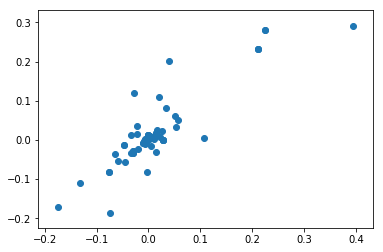

In [64]:
## the below figure shows the word embedding means clusterring the similar words together.
plt.scatter(review_words[:,0], review_words[:,1])